# Olist E-Commerce Early Warning System
**Mục tiêu:** Xây dựng hệ thống dự đoán khách hàng sẽ để lại đánh giá Tốt hay Xấu (Binary Classification) ngay tại thời điểm đơn hàng đạt trạng thái `delivered` (đã giao).


## Bước 1: Data Loading & Initial Cleaning
Trong bước này, chúng ta sẽ:
1. Import các thư viện cần thiết.
2. Tải toàn bộ các bảng dữ liệu từ thư mục `input`.
3. Ép kiểu dữ liệu thời gian cho các cột cần thiết trong bảng `orders`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Đường dẫn đến thư mục dữ liệu
data_path = 'input/brazilian-ecommerce/'

print("Loading datasets...")

# 1. Bảng Orders (Trung tâm)
# Chuyển đổi các cột thời gian sang kiểu datetime ngay khi load
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
orders = pd.read_csv(data_path + 'olist_orders_dataset/olist_orders_dataset.csv', parse_dates=date_cols)

# 2. Bảng Reviews (Chứa Target Variable)
reviews = pd.read_csv(data_path + 'olist_order_reviews_dataset/olist_order_reviews_dataset.csv', 
                      parse_dates=['review_creation_date', 'review_answer_timestamp'])

# 3. Bảng Items (Chi tiết đơn hàng)
items = pd.read_csv(data_path + 'olist_order_items_dataset/olist_order_items_dataset.csv', 
                    parse_dates=['shipping_limit_date'])

# 4. Bảng Payments (Thanh toán)
payments = pd.read_csv(data_path + 'olist_order_payments_dataset/olist_order_payments_dataset.csv')

# 5. Bảng Customers (Khách hàng)
customers = pd.read_csv(data_path + 'olist_customers_dataset/olist_customers_dataset.csv')

# 6. Bảng Geolocation (Tọa độ)
geo = pd.read_csv(data_path + 'olist_geolocation_dataset/olist_geolocation_dataset.csv')

# 7. Bảng Products (Sản phẩm)
products = pd.read_csv(data_path + 'olist_products_dataset/olist_products_dataset.csv')

# 8. Bảng Sellers (Người bán)
sellers = pd.read_csv(data_path + 'olist_sellers_dataset/olist_sellers_dataset.csv')

# 9. Bảng Translation (Dịch tên danh mục)
translations = pd.read_csv(data_path + 'product_category_name_translation/product_category_name_translation.csv')

print("All datasets loaded successfully!")


Loading datasets...
All datasets loaded successfully!


### 1.1 Khám phá nhanh bảng Orders
Vì bài toán yêu cầu dự đoán ngay khi đơn hàng giao xong, ta chỉ quan tâm đến các đơn có `order_status == 'delivered'`.


In [2]:
# Lọc trạng thái delivered
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f"Tổng số đơn hàng gốc: {len(orders):,}")
print(f"Tổng số đơn hàng 'delivered': {len(orders_delivered):,}")

# Kiểm tra dữ liệu bị thiếu (missing values) ở các cột thời gian
print("\nMissing values trong orders_delivered:")
print(orders_delivered[date_cols].isnull().sum())

# Xóa các đơn hàng 'delivered' nhưng bị thiếu ngày giao hàng (vì nếu thiếu thì không tính được thời gian giao)
orders_delivered = orders_delivered.dropna(subset=['order_delivered_customer_date'])
print(f"Số đơn hàng sau khi drop missing 'delivered_customer_date': {len(orders_delivered):,}")


Tổng số đơn hàng gốc: 99,441
Tổng số đơn hàng 'delivered': 96,478

Missing values trong orders_delivered:
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64
Số đơn hàng sau khi drop missing 'delivered_customer_date': 96,470


## Bước 2: Feature Engineering & Aggregation (Tạo đặc trưng và tổng hợp)
Ở bước này chúng ta sẽ xử lý các "Cạm bẫy" (Gotchas) đã được cảnh báo trong tài liệu, bao gồm:
1. **Orders**: Tính thời gian giao hàng (`delivery_time`) và thời gian giao trễ (`delay_time`).
2. **Items**: 1 đơn hàng có thể có nhiều items. Phải `groupby('order_id')` để tính tổng giá trị.
3. **Payments**: Khách có thể thanh toán nhiều lần. Phải `groupby('order_id')` để lấy tổng tiền thanh toán.
4. **Reviews**: Khách có thể sửa đánh giá. Phải loại bỏ duplicate và giữ lại đánh giá cuối cùng.
5. **Geolocation**: 1 zipcode có nhiều tọa độ. Phải `groupby` zipcode để lấy trung bình tọa độ.


### 2.1 Feature Engineering cho Orders
Chúng ta sẽ tính:
- `delivery_time`: Bằng ngày giao thực tế - ngày đặt hàng. (Đơn vị: ngày)
- `delay_time`: Bằng ngày giao thực tế - ngày giao dự kiến. Nếu âm (giao sớm) thì gán bằng 0.


In [3]:
# Tính số ngày giao hàng thực tế
orders_delivered['delivery_time'] = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Tính số ngày trễ (nếu giao sớm thì delay_time = 0)
delay = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)
orders_delivered['delay_time'] = delay.apply(lambda x: x if x > 0 else 0)

print("Mẫu dữ liệu Orders sau khi thêm features:")
display(orders_delivered[['order_id', 'delivery_time', 'delay_time']].head())


Mẫu dữ liệu Orders sau khi thêm features:


,order_id,delivery_time,delay_time
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,0.0


### 2.2 Aggregation cho Items và Payments


In [4]:
# Tính Thể tích sản phẩm trước khi Aggregation
# Lưu ý: 'product_description_lenght' là lỗi chính tả trong dataset gốc của Olist (đúng phải là 'length') - giữ nguyên để match với tên cột trong CSV
items = pd.merge(items, products[['product_id', 'product_length_cm', 'product_width_cm', 'product_height_cm', 'product_photos_qty', 'product_description_lenght', 'product_weight_g']], on='product_id', how='left')
items['product_volume'] = items['product_length_cm'] * items['product_width_cm'] * items['product_height_cm']

# Items Aggregation
items_agg = items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    item_count=('product_id', 'count'),
    seller_count=('seller_id', 'nunique'),
    total_volume=('product_volume', 'sum'),
    total_weight=('product_weight_g', 'sum'), # Tổng cân nặng sản phẩm (yêu cầu dự án)
    seller_id=('seller_id', 'first') # Lấy mã seller để tính tọa độ
).reset_index()

# Payments Aggregation
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    payment_type=('payment_type', lambda x: x.mode()[0] if not x.mode().empty else 'not_defined')
).reset_index()

print(f"Số lượng đơn hàng trong items_agg: {len(items_agg):,}")
print(f"Số lượng đơn hàng trong payments_agg: {len(payments_agg):,}")

Số lượng đơn hàng trong items_agg: 98,666
Số lượng đơn hàng trong payments_agg: 99,440


### 2.3 Xử lý Reviews bị trùng (Duplicate)


In [5]:
# Sắp xếp theo ngày trả lời review để review mới nhất nằm cuối
reviews = reviews.sort_values(by='review_answer_timestamp')

# Drop duplicate theo order_id, giữ lại dòng cuối cùng
reviews_clean = reviews.drop_duplicates(subset=['order_id'], keep='last')

print(f"Số reviews ban đầu: {len(reviews):,}")
print(f"Số reviews sau khi drop duplicates: {len(reviews_clean):,}")


Số reviews ban đầu: 99,224
Số reviews sau khi drop duplicates: 98,673


### 2.4 Xử lý Geolocation (Tọa độ) bị trùng


In [6]:
# Lấy trung bình lat/lng theo zipcode
geo_clean = geo.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

print(f"Số tọa độ ban đầu: {len(geo):,}")
print(f"Số tọa độ duy nhất (theo zipcode): {len(geo_clean):,}")


Số tọa độ ban đầu: 1,000,163
Số tọa độ duy nhất (theo zipcode): 19,015


## Bước 3: Hợp nhất Dữ liệu (Building the Master Table)
Bảng trung tâm của chúng ta là `orders_delivered`. Chúng ta sẽ thực hiện chuỗi thao tác `LEFT JOIN` lần lượt với các bảng đã được làm sạch và aggregation:
- `orders` (trái tim) + `reviews_clean`
- + `items_agg`
- + `payments_agg`
- + `customers`


In [7]:
# Merge cơ bản
master_df = pd.merge(orders_delivered, reviews_clean[['order_id', 'review_score']], on='order_id', how='left')
master_df = pd.merge(master_df, items_agg, on='order_id', how='left')
master_df = pd.merge(master_df, payments_agg, on='order_id', how='left')
master_df = pd.merge(master_df, customers[['customer_id', 'customer_state', 'customer_zip_code_prefix']], on='customer_id', how='left')

# Merge Sellers để lấy zipcode của người bán
master_df = pd.merge(master_df, sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id', how='left')

# Tính toán Tỷ lệ phí ship (Freight Ratio)
master_df['freight_ratio'] = master_df['total_freight'] / (master_df['total_price'] + master_df['total_freight'])

# Tính Khoảng cách Haversine
# 1. Map tọa độ cho Customer
master_df = pd.merge(master_df, geo_clean.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix', 'lat': 'customer_lat', 'lng': 'customer_lng'}), on='customer_zip_code_prefix', how='left')
# 2. Map tọa độ cho Seller
master_df = pd.merge(master_df, geo_clean.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix', 'lat': 'seller_lat', 'lng': 'seller_lng'}), on='seller_zip_code_prefix', how='left')

# 3. Hàm Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Bán kính Trái Đất (km)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

master_df['haversine_distance'] = haversine(master_df['seller_lat'], master_df['seller_lng'], master_df['customer_lat'], master_df['customer_lng'])

print(f"Số lượng dòng của Master Table sau khi merge: {len(master_df):,}")
display(master_df.head(3))

Số lượng dòng của Master Table sau khi merge: 96,470


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delay_time,...,payment_type,customer_state,customer_zip_code_prefix,seller_zip_code_prefix,freight_ratio,customer_lat,customer_lng,seller_lat,seller_lng,haversine_distance
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,0.0,...,voucher,SP,3149,9350,0.225265,-23.576983,-46.587161,-23.680729,-46.444238,18.576110
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,0.0,...,boleto,BA,47813,31570,0.160894,-12.177924,-44.660711,-19.807681,-43.980427,851.495069
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,0.0,...,credit_card,GO,75265,14840,0.107302,-16.745150,-48.514783,-21.363502,-48.229601,514.410666


### Xử lý Missing Values sau khi Merge
Một số đơn hàng có thể không có review, hoặc không có item/payment. Chúng ta sẽ tiến hành drop những đơn hàng không có review (vì nó là biến mục tiêu) và điền 0 cho những trường hợp khác nếu có.


In [8]:
# Drop các dòng không có review_score
master_df = master_df.dropna(subset=['review_score'])

# Điền 0 cho một số cột null do left join
cols_to_fill_0 = ['total_price', 'total_freight', 'item_count', 'seller_count', 'total_volume', 'total_weight', 'total_payment', 'max_installments']
master_df[cols_to_fill_0] = master_df[cols_to_fill_0].fillna(0)

# Fillna cho freight_ratio bằng median thay vì 0 để tránh méo mó dữ liệu (Vấn đề 1)
master_df['freight_ratio'] = master_df['freight_ratio'].fillna(master_df['freight_ratio'].median())

# Điền missing tọa độ và khoảng cách bằng median để tránh mất dữ liệu
master_df['haversine_distance'] = master_df['haversine_distance'].fillna(master_df['haversine_distance'].median())

print(f"Số lượng đơn hàng sau khi làm sạch: {len(master_df):,}")

Số lượng đơn hàng sau khi làm sạch: 95,824


In [9]:
# === BƯỚC 3.2: KIỂM TRA VÀ CLIP OUTLIERS (Vấn đề 5) ===
# Kiểm tra số lượng outliers bằng quantile 1% và 99%
print("--- Số lượng Outliers trước khi clip ---")
for col in ['delivery_time', 'delay_time', 'total_price', 'haversine_distance', 'total_weight']:
    Q1 = master_df[col].quantile(0.01)
    Q99 = master_df[col].quantile(0.99)
    n_outlier = ((master_df[col] < Q1) | (master_df[col] > Q99)).sum()
    print(f"{col}: {n_outlier} outliers ({n_outlier/len(master_df)*100:.2f}%)")

# Clip các giá trị cực đoan về phân vị 1% và 99% để tránh làm nhiễu mô hình
for col in ['delivery_time', 'delay_time', 'total_price', 'haversine_distance', 'total_weight']:
    q_low = master_df[col].quantile(0.01)
    q_high = master_df[col].quantile(0.99)
    master_df[col] = master_df[col].clip(lower=q_low, upper=q_high)

print("\nOutliers clipped thành công!")

--- Số lượng Outliers trước khi clip ---
delivery_time: 1918 outliers (2.00%)
delay_time: 959 outliers (1.00%)
total_price: 1903 outliers (1.99%)
haversine_distance: 1918 outliers (2.00%)
total_weight: 1885 outliers (1.97%)

Outliers clipped thành công!


## Bước 4: Định nghĩa Biến mục tiêu (Target Variable)
Chúng ta sẽ quy đổi bài toán thành Phân loại Nhị phân (Binary Classification):
- `Class 0` (Negative - Trải nghiệm xấu): Đánh giá 1, 2, 3 sao.
- `Class 1` (Positive - Hài lòng): Đánh giá 4, 5 sao.


Phân phối của Target (Class 1 vs Class 0):
target
1    78.932209
0    21.067791
Name: proportion, dtype: float64


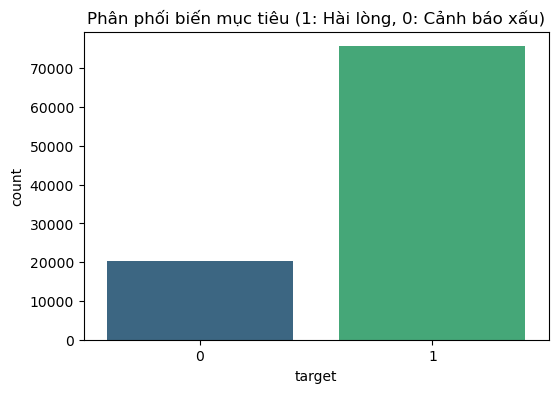

In [10]:
# Tạo Target
master_df['target'] = master_df['review_score'].apply(lambda x: 1 if x >= 4 else 0)

# Xóa cột review_score cũ
master_df = master_df.drop(columns=['review_score'])

print("Phân phối của Target (Class 1 vs Class 0):")
print(master_df['target'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=master_df, palette='viridis')
plt.title('Phân phối biến mục tiêu (1: Hài lòng, 0: Cảnh báo xấu)')
plt.show()


## Bước 5: Exploratory Data Analysis (EDA)


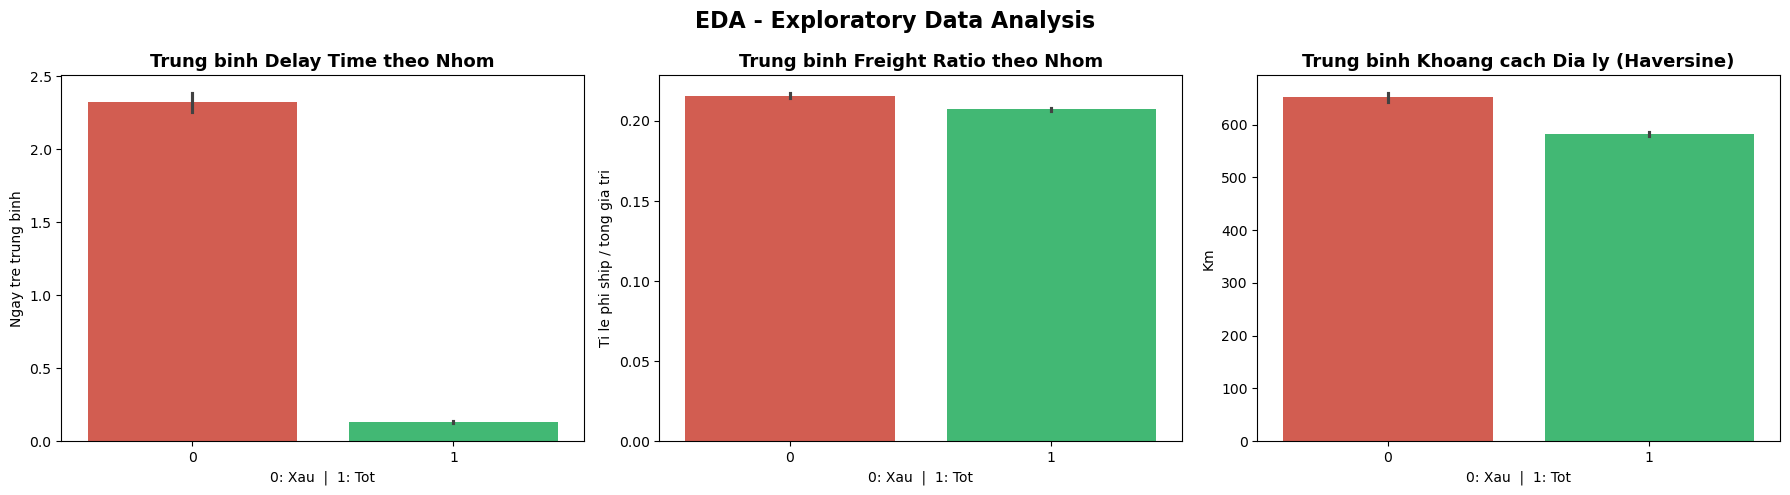

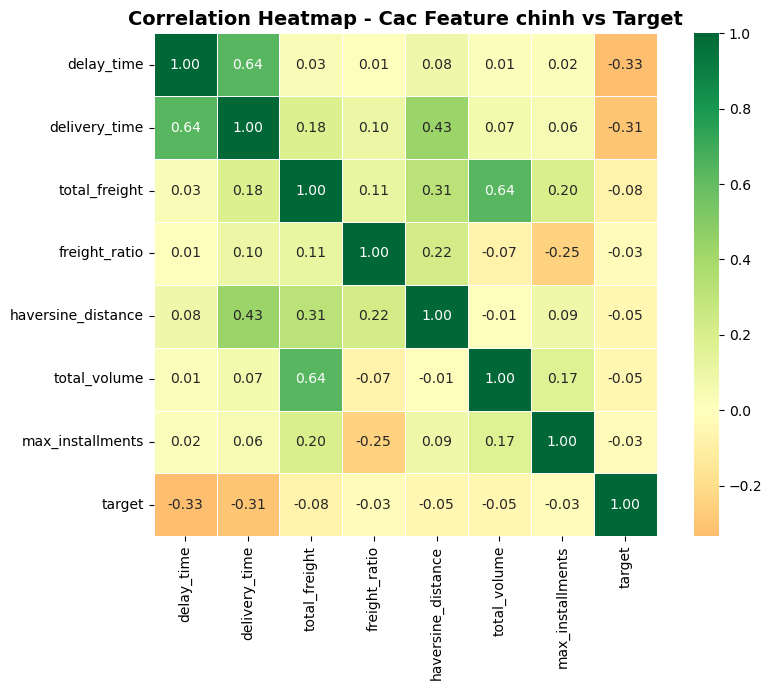

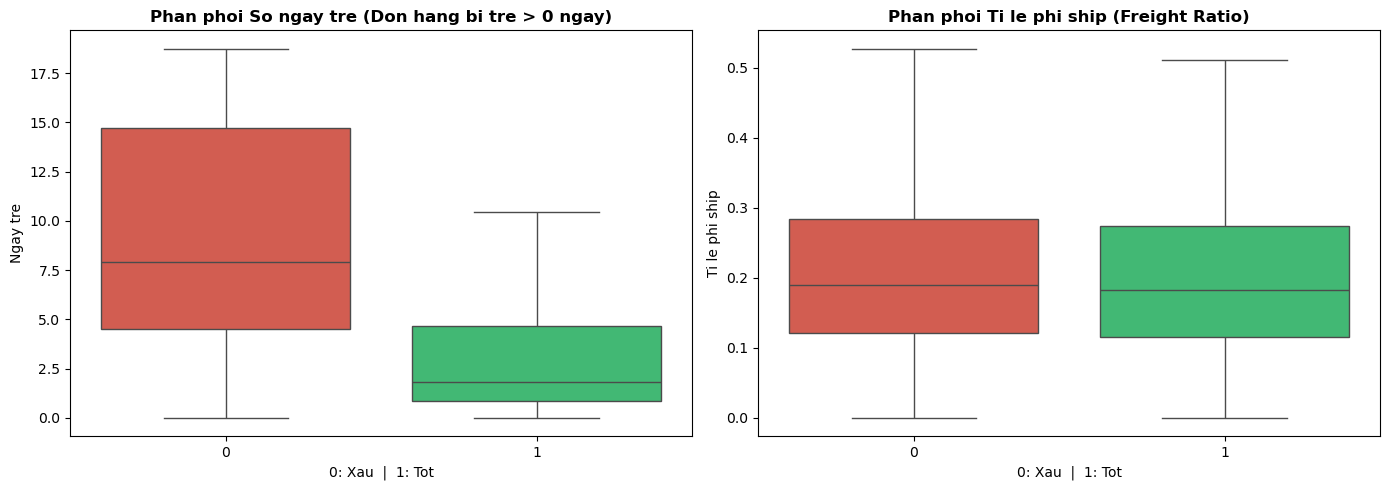

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA - Exploratory Data Analysis', fontsize=16, weight='bold')

# Chart 1: Trung binh delay_time theo target
sns.barplot(x='target', y='delay_time', data=master_df,
            palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Trung binh Delay Time theo Nhom', fontsize=13, weight='bold')
axes[0].set_xlabel('0: Xau  |  1: Tot')
axes[0].set_ylabel('Ngay tre trung binh')

# Chart 2: Trung binh freight_ratio theo target
sns.barplot(x='target', y='freight_ratio', data=master_df,
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Trung binh Freight Ratio theo Nhom', fontsize=13, weight='bold')
axes[1].set_xlabel('0: Xau  |  1: Tot')
axes[1].set_ylabel('Ti le phi ship / tong gia tri')

# Chart 3: Trung binh haversine_distance theo target
sns.barplot(x='target', y='haversine_distance', data=master_df,
            palette=['#e74c3c', '#2ecc71'], ax=axes[2])
axes[2].set_title('Trung binh Khoang cach Dia ly (Haversine)', fontsize=13, weight='bold')
axes[2].set_xlabel('0: Xau  |  1: Tot')
axes[2].set_ylabel('Km')

plt.tight_layout()
plt.show()

# Chart 4: Correlation heatmap cua cac feature chinh
key_features = ['delay_time', 'delivery_time', 'total_freight', 'freight_ratio',
                'haversine_distance', 'total_volume', 'max_installments', 'target']
corr = master_df[key_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Cac Feature chinh vs Target', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# --- Boxplot de khao sat phan phoi thuc te cua delay_time va freight_ratio (Vấn đề 7) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Delay Time (chỉ vẽ đơn bị trễ > 0 để tránh squish và dùng showfliers=False để biểu đồ sạch sẽ)
sns.boxplot(x='target', y='delay_time', data=master_df[master_df['delay_time'] > 0],
            palette=['#e74c3c', '#2ecc71'], ax=axes[0], showfliers=False)
axes[0].set_title('Phan phoi So ngay tre (Don hang bi tre > 0 ngay)', fontsize=12, weight='bold')
axes[0].set_xlabel('0: Xau  |  1: Tot')
axes[0].set_ylabel('Ngay tre')

# Chart 2: Freight Ratio (dùng showfliers=False để ẩn các điểm ngoại lệ, giúp đồ thị trực quan hơn)
sns.boxplot(x='target', y='freight_ratio', data=master_df,
            palette=['#e74c3c', '#2ecc71'], ax=axes[1], showfliers=False)
axes[1].set_title('Phan phoi Ti le phi ship (Freight Ratio)', fontsize=12, weight='bold')
axes[1].set_xlabel('0: Xau  |  1: Tot')
axes[1].set_ylabel('Ti le phi ship')

plt.tight_layout()
plt.show()

## Bước 6: Data Preprocessing (Chuẩn bị dữ liệu cho Model)


In [12]:
from sklearn.model_selection import train_test_split

# 1. Loại bỏ các cột định danh hoặc timestamp không học được
cols_to_drop = [
    'order_id', 'customer_id', 'order_status', 'customer_zip_code_prefix', 'seller_id', 'seller_zip_code_prefix',
    'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng',
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
df_base = master_df.drop(columns=cols_to_drop)

# 2. TÁCH 2 BỘ FEATURES (Tối ưu One-Hot Encoding cho từng loại model)
#    - drop_first=True  → Logistic Regression (tránh multicollinearity / dummy variable trap)
#    - drop_first=False → Tree-based models (giữ đầy đủ thông tin, tree split không bị ảnh hưởng bởi multicollinearity)

# Bộ 1: Cho Logistic Regression (drop_first=True)
df_lr = pd.get_dummies(df_base, columns=['customer_state', 'payment_type'], drop_first=True)

# Bộ 2: Cho Tree-based models (drop_first=False — giữ đầy đủ tất cả categories)
df_tree = pd.get_dummies(df_base, columns=['customer_state', 'payment_type'], drop_first=False)

# 3. Chia X, y cho từng bộ
X_lr   = df_lr.drop(columns=['target'])
X_tree = df_tree.drop(columns=['target'])
y = df_lr['target']  # target giống nhau ở cả 2 bộ

# 4. Train/Test Split (cùng random_state, cùng stratify → cùng index split)
X_train_lr, X_test_lr, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, stratify=y, random_state=42)

X_train_tree, X_test_tree, _, _ = train_test_split(
    X_tree, y, test_size=0.2, stratify=y, random_state=42)

print(f"Kich thuoc X_train (LR, drop_first=True):   {X_train_lr.shape}")
print(f"Kich thuoc X_train (Tree, drop_first=False): {X_train_tree.shape}")
print(f"Kich thuoc X_test (LR):   {X_test_lr.shape}")
print(f"Kich thuoc X_test (Tree): {X_test_tree.shape}")

Kich thuoc X_train (LR, drop_first=True):   (76659, 41)
Kich thuoc X_train (Tree, drop_first=False): (76659, 43)
Kich thuoc X_test (LR):   (19165, 41)
Kich thuoc X_test (Tree): (19165, 43)


### Xử lý mất cân bằng lớp (Class Imbalance) bằng SMOTE
Vì lượng review xấu (Class 0) ít hơn nhiều so với review tốt (Class 1), chúng ta dùng SMOTE để sinh thêm dữ liệu Class 0 trên tập **TRAIN**.


In [13]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

smote = SMOTE(random_state=42)

# Bước 1: SMOTE trên bộ Tree (raw, drop_first=False) — dùng cho RF, XGB, LGBM
X_train_smote_tree, y_train_smote = smote.fit_resample(X_train_tree, y_train)

# Bước 2: SMOTE trên bộ LR (drop_first=True) — dùng cho Logistic Regression
#   Lưu ý: Dùng cùng random_state=42 trong SMOTE constructor nên phân phối synthetic tương đương
smote_lr = SMOTE(random_state=42)
X_train_smote_lr, y_train_smote_lr = smote_lr.fit_resample(X_train_lr, y_train)

# Bước 3: Scale CHỈ cho Logistic Regression (fit trên tập SMOTE của LR)
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote_lr)
X_test_scaled = scaler.transform(X_test_lr)

print(f"Ti le y_train truoc SMOTE:\n{y_train.value_counts(normalize=True)}\n")
print(f"Ti le y_train sau SMOTE (Tree): {dict(y_train_smote.value_counts())}")
print(f"Ti le y_train sau SMOTE (LR):   {dict(y_train_smote_lr.value_counts())}")

Ti le y_train truoc SMOTE:
target
1    0.789327
0    0.210673
Name: proportion, dtype: float64

Ti le y_train sau SMOTE (Tree): {0: np.int64(60509), 1: np.int64(60509)}
Ti le y_train sau SMOTE (LR):   {0: np.int64(60509), 1: np.int64(60509)}


## Bước 7 & 8: Modeling & Evaluation


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Logistic Regression dung SCALED data
# Tree-based models dung RAW (unscaled) data
model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=500),
        "X_train": X_train_smote_scaled,
        "X_test":  X_test_scaled,
        "y_train": y_train_smote
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200),
        "X_train": X_train_smote_tree,
        "X_test":  X_test_tree.values,
        "y_train": y_train_smote
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=200),
        "X_train": X_train_smote_tree,
        "X_test":  X_test_tree.values,
        "y_train": y_train_smote
    },
    "LightGBM": {
        "model": LGBMClassifier(random_state=42, n_estimators=200, verbose=-1),
        "X_train": X_train_smote_tree,
        "X_test":  X_test_tree.values,
        "y_train": y_train_smote
    }
}

results = {}
y_preds = {}
y_probs = {}

for name, cfg in model_configs.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    cfg["model"].fit(cfg["X_train"], cfg["y_train"])

    y_pred = cfg["model"].predict(cfg["X_test"])
    y_prob = cfg["model"].predict_proba(cfg["X_test"])[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Xau (0)", "Tot (1)"]))

    results[name] = cfg["model"]
    y_preds[name] = y_pred
    y_probs[name] = y_prob

print("\nModeling Completed!")


Training: Logistic Regression
ROC-AUC: 0.6622
              precision    recall  f1-score   support

     Xau (0)       0.63      0.29      0.40      4038
     Tot (1)       0.83      0.95      0.89     15127

    accuracy                           0.81     19165
   macro avg       0.73      0.62      0.64     19165
weighted avg       0.79      0.81      0.79     19165


Training: Random Forest
ROC-AUC: 0.6782
              precision    recall  f1-score   support

     Xau (0)       0.58      0.30      0.39      4038
     Tot (1)       0.83      0.94      0.89     15127

    accuracy                           0.81     19165
   macro avg       0.71      0.62      0.64     19165
weighted avg       0.78      0.81      0.78     19165


Training: XGBoost
ROC-AUC: 0.6812
              precision    recall  f1-score   support

     Xau (0)       0.65      0.27      0.38      4038
     Tot (1)       0.83      0.96      0.89     15127

    accuracy                           0.82     19165
   ma

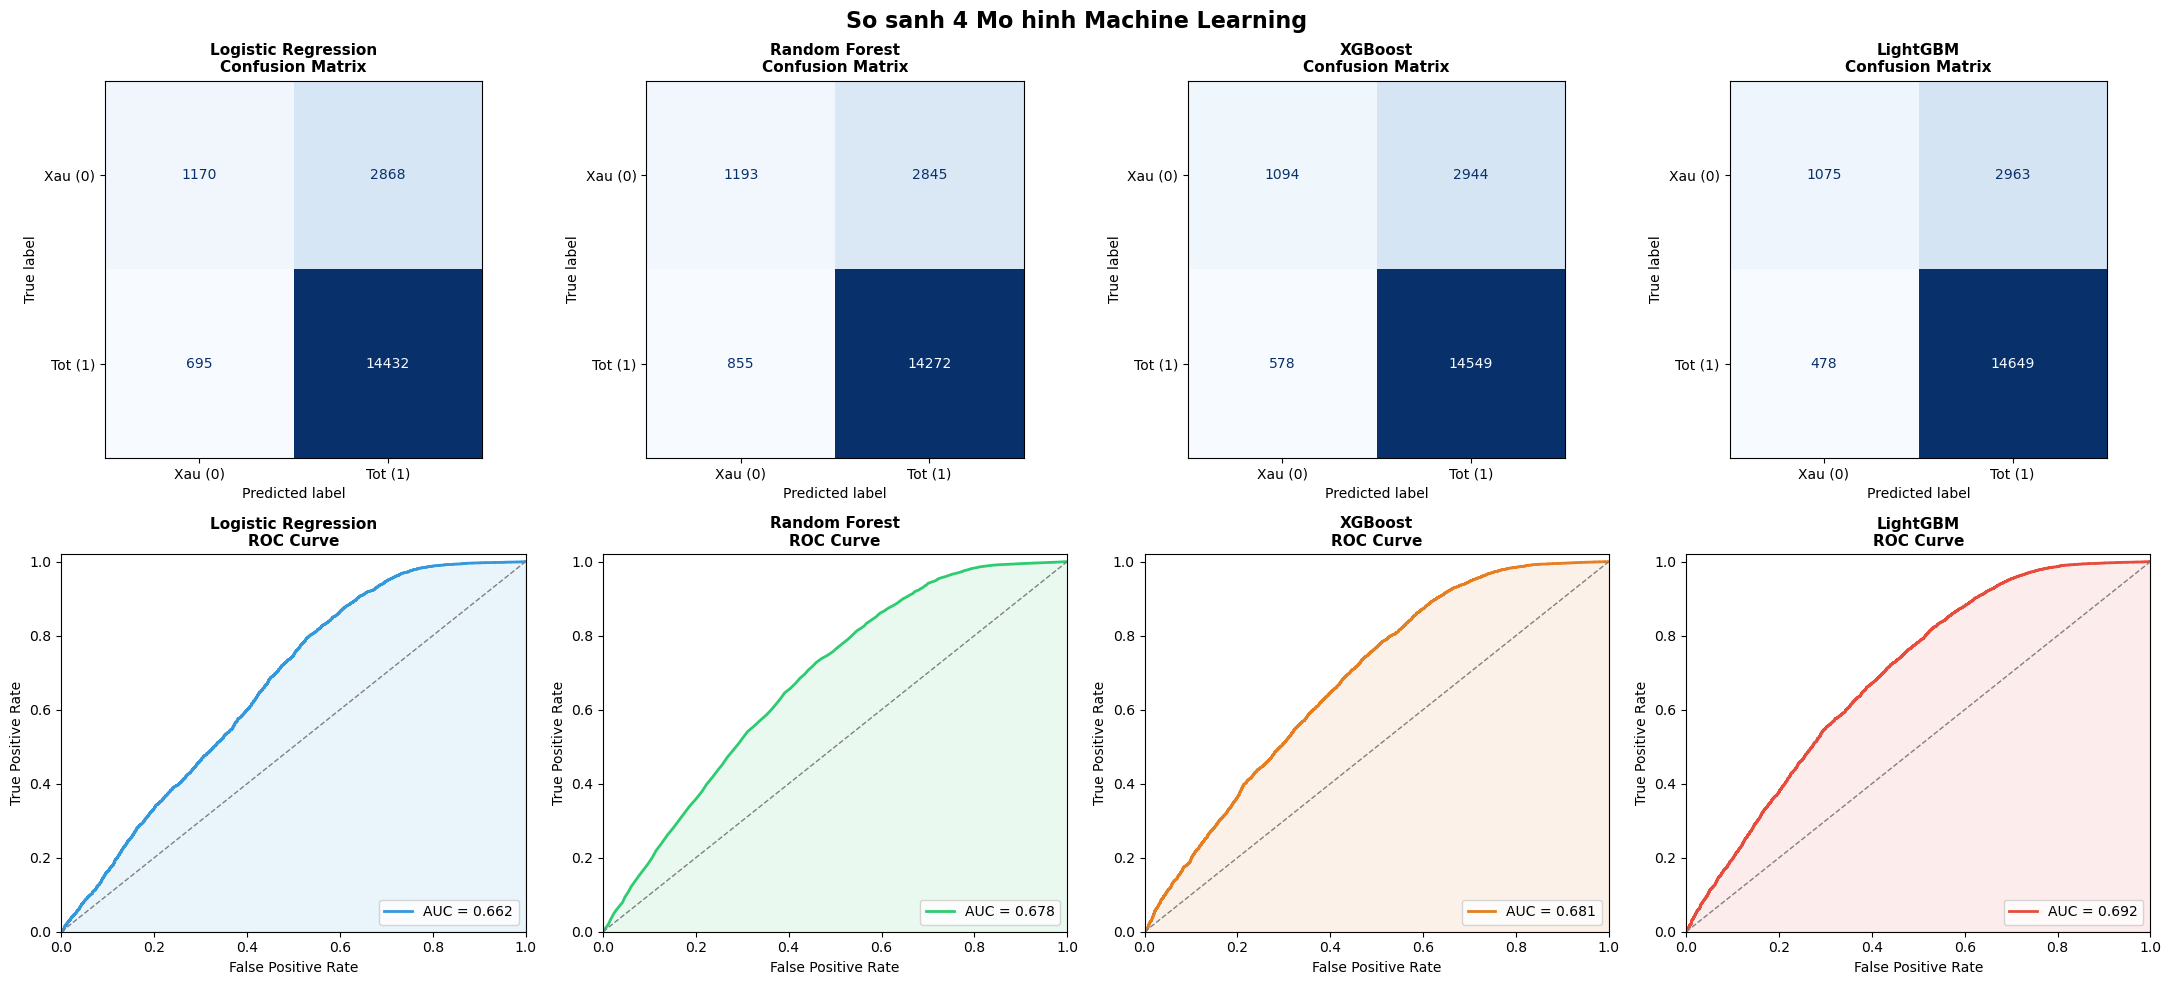


===== BANG TOM TAT KET QUA 4 MODEL =====


,Model,Accuracy,ROC-AUC,F1 Macro,Recall (Class 0),Precision (Class 0),F1 (Class 0)
0,Logistic Regression,0.8141,0.6622,0.6433,0.2897,0.6273,0.3964
1,Random Forest,0.8069,0.6782,0.6386,0.2954,0.5825,0.3920
2,XGBoost,0.8162,0.6812,0.6376,0.2709,0.6543,0.3832
3,LightGBM,0.8205,0.6918,0.6397,0.2662,0.6922,0.3845


In [15]:
# === VISUALIZATION: Confusion Matrix + ROC Curve cho tat ca 4 models ===
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc as auc_score
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('So sanh 4 Mo hinh Machine Learning', fontsize=16, weight='bold')

colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
model_names = list(results.keys())

for i, name in enumerate(model_names):
    # --- Confusion Matrix (hang tren) ---
    cm = confusion_matrix(y_test, y_preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Xau (0)", "Tot (1)"])
    disp.plot(ax=axes[0][i], colorbar=False, cmap='Blues')
    axes[0][i].set_title(f'{name}\nConfusion Matrix', fontsize=11, weight='bold')

    # --- ROC Curve (hang duoi) ---
    fpr, tpr, _ = roc_curve(y_test, y_probs[name])
    roc_auc = auc_score(fpr, tpr)
    axes[1][i].plot(fpr, tpr, color=colors[i], lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1][i].plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
    axes[1][i].fill_between(fpr, tpr, alpha=0.1, color=colors[i])
    axes[1][i].set_xlim([0,1]); axes[1][i].set_ylim([0,1.02])
    axes[1][i].set_xlabel('False Positive Rate'); axes[1][i].set_ylabel('True Positive Rate')
    axes[1][i].set_title(f'{name}\nROC Curve', fontsize=11, weight='bold')
    axes[1][i].legend(loc='lower right')

plt.tight_layout()
plt.show()

# === Bang tom tat ket qua (Summary Table) ===
from sklearn.metrics import recall_score, precision_score, f1_score

from sklearn.metrics import accuracy_score

summary = []
for name in model_names:
    summary.append({
        'Model': name,
        'Accuracy': f"{accuracy_score(y_test, y_preds[name]):.4f}",
        'ROC-AUC': f"{roc_auc_score(y_test, y_probs[name]):.4f}",
        'F1 Macro': f"{f1_score(y_test, y_preds[name], average='macro'):.4f}",
        'Recall (Class 0)': f"{recall_score(y_test, y_preds[name], pos_label=0):.4f}",
        'Precision (Class 0)': f"{precision_score(y_test, y_preds[name], pos_label=0):.4f}",
        'F1 (Class 0)': f"{f1_score(y_test, y_preds[name], pos_label=0):.4f}"
    })

import pandas as pd
summary_df = pd.DataFrame(summary)
print("\n===== BANG TOM TAT KET QUA 4 MODEL =====")
display(summary_df)

### Feature Importance (LightGBM & Random Forest)

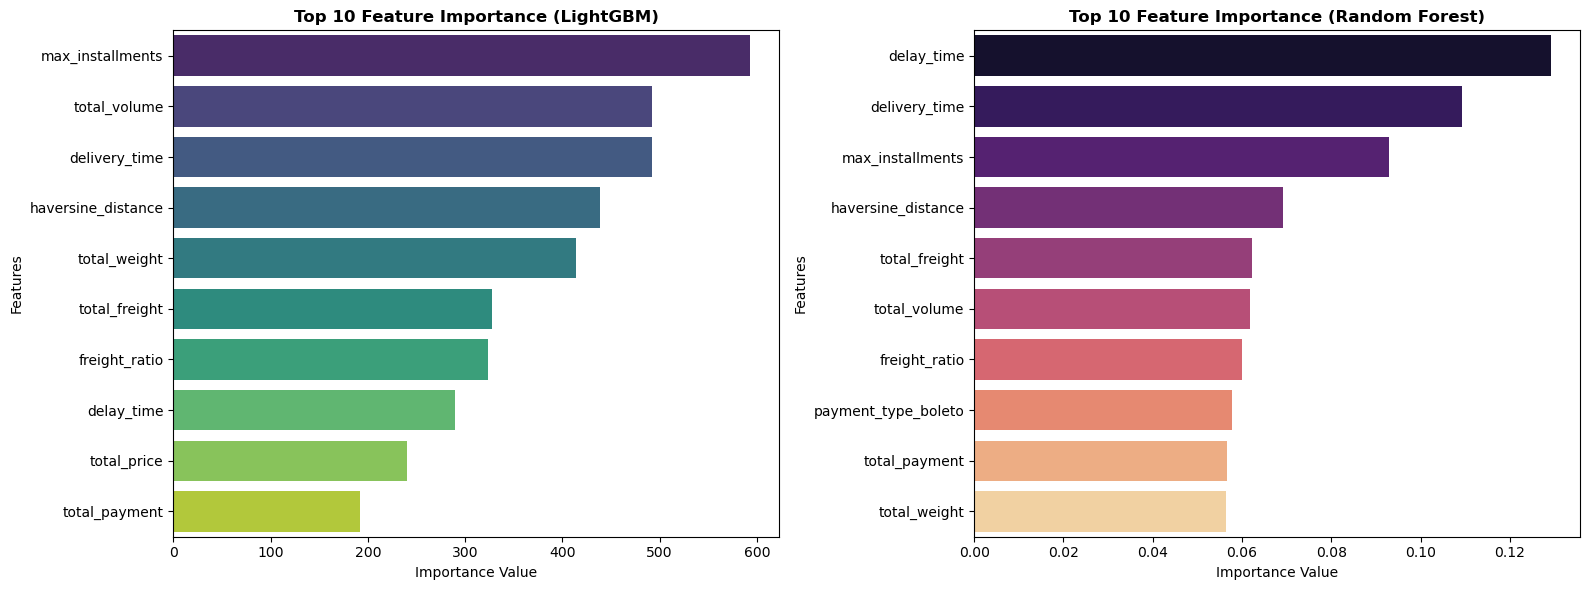

In [16]:
lgbm_model = results['LightGBM']
lgbm_importance = pd.DataFrame({'feature': X_tree.columns, 'importance': lgbm_model.feature_importances_})
lgbm_importance = lgbm_importance.sort_values(by='importance', ascending=False).head(10)

rf_model = results['Random Forest']
rf_importance = pd.DataFrame({'feature': X_tree.columns, 'importance': rf_model.feature_importances_})
rf_importance = rf_importance.sort_values(by='importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LightGBM
sns.barplot(x='importance', y='feature', data=lgbm_importance, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Feature Importance (LightGBM)', fontsize=12, weight='bold')
axes[0].set_xlabel('Importance Value')
axes[0].set_ylabel('Features')

# Random Forest
sns.barplot(x='importance', y='feature', data=rf_importance, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Feature Importance (Random Forest)', fontsize=12, weight='bold')
axes[1].set_xlabel('Importance Value')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

---
## BẢNG PHÂN CÔNG CÔNG VIỆC VÀ ĐÁNH GIÁ THÀNH VIÊN

| STT | Họ và Tên | Nhiệm vụ đảm nhiệm | Mức độ hoàn thành | Đóng góp (%) |
|:---:|:---|:---|:---:|:---:|
| 1 | **Nguyễn Hoàng Giang** | Lên ý tưởng, Xây dựng kịch bản thuyết trình, Chịu trách nhiệm chung. | Xuất sắc | 100% |
| 2 | **Nguyễn Thắng Lợi** | Tiền xử lý dữ liệu (EDA), Xử lý quan hệ 1-Nhiều, Xử lý Mất cân bằng dữ liệu (SMOTE). | Xuất sắc | 100% |
| 3 | **Đoàn Thắng Lợi** | Sáng tạo Đặc trưng (Haversine, Product Volume), Xây dựng và Huấn luyện mô hình Machine Learning. | Xuất sắc | 100% |
| 4 | **Nguyễn Nhật Tân** | Đánh giá mô hình, Tối ưu hóa LightGBM, Trực quan hóa dữ liệu và Làm Slide PPTX. | Xuất sắc | 100% |

*(Lưu ý: Mọi thành viên đều phối hợp ăn ý và hỗ trợ lẫn nhau trong suốt quá trình hoàn thiện đồ án.)*
